In [2]:
!curl -O https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12.9M  100 12.9M    0     0   489k      0  0:00:27  0:00:27 --:--:-- 1432k
Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [32]:
import os

fname= os.path.join("jena_climate_2009_2016.csv")
with open(fname) as f:
    data= f.read()

lines= data.split("\n")
header= lines[0].split(",")
lines= lines[1:]
print(header)
print(len(lines))


['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [33]:
import numpy as np
temperature= np.zeros((len(lines),))
raw_data= np.zeros((len(lines),len(header)-1))

for i, line in enumerate(lines):
    values= [float(x) for x in line.split(",")[1:]]
    temperature[i]= values[1]
    raw_data[i,:]= values[:]
    

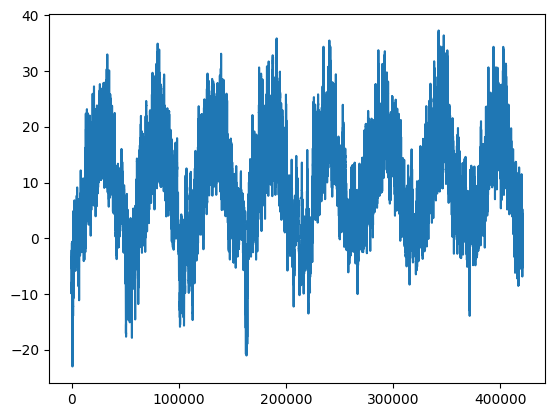

In [34]:
import matplotlib.pyplot as plt

plt.plot(range(len(temperature)),temperature)

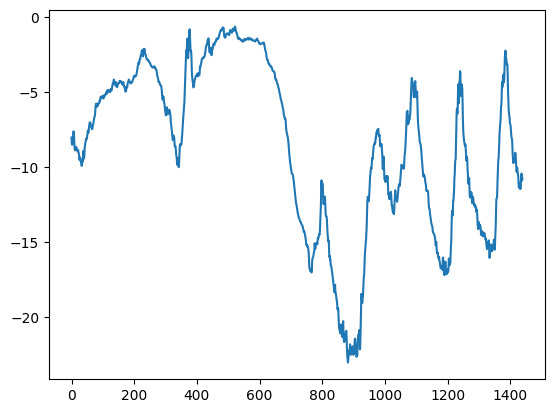

In [35]:
plt.plot(range(1440),temperature[:1440])
#data over first 10 days, as data is recorded every 10 mins, thereform 24x6= 144 a day

In [36]:
num_train_samples= int(0.5*len(raw_data))
num_val_samples=int(0.25*len(raw_data))
num_test_samples = len(raw_data) - num_train_samples- num_val_samples
print("num_train_samples:", num_train_samples)
print("num_validation_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)


num_train_samples: 210225
num_validation_samples: 105112
num_test_samples: 105114


In [37]:
mean= raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std= raw_data[:num_train_samples].std(axis=0)
raw_data/= std

In [39]:
import keras 

sampling_rate=6
sequence_length=120
delay= sampling_rate*(sequence_length+24-1)
batch_size=256

train_dataset= keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets= temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)

val_dataset= keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets= temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples+ num_val_samples,
)

test_dataset= keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets= temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples+ num_val_samples,
)

In [41]:
for samples, targets in train_dataset:
    print("sample shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

sample shape: (256, 120, 14)
targets shape: (256,)


In [42]:
def evaluate_naive_method(dataset):
    total_abs_err= 0.0
    samples_seen=0
    for samples,targets in dataset:
        preds = samples[:,-1,1]*std[1]+ mean[1]
        total_abs_err += np.sum(np.abs(preds-targets))
        samples_seen+= samples.shape[0]
    return total_abs_err/samples_seen
print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

2026-06-14 17:00:22.886104: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Validation MAE: 2.44
Test MAE: 2.62


In [44]:
import keras
from keras import layers

inputs= keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x= layers.Flatten()(inputs)
x= layers.Dense(16, activation="relu")(x)
outputs= layers.Dense(1)(x)
model= keras.Model(inputs,outputs)
callbacks= [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
history= model.fit(
    train_dataset,
    epochs=10,
    validation_data= val_dataset,
    callbacks=callbacks,
)
model= keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.0514 - mae: 2.8514 - val_loss: 11.1266 - val_mae: 2.6244
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 9.0368 - mae: 2.3604 - val_loss: 10.9379 - val_mae: 2.6132
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.3088 - mae: 2.2656 - val_loss: 11.2672 - val_mae: 2.6602
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7.8424 - mae: 2.2057 - val_loss: 11.5631 - val_mae: 2.6860
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7.4387 - mae: 2.1505 - val_loss: 11.7439 - val_mae: 2.7064
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7.1482 - mae: 2.1099 - val_loss: 11.5837 - val_mae: 2.6747
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6.9517 - mae: 2.0816 - val_loss: 11.5547 - val_mae: 2.6747
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6.7600 - mae: 2.0519 - val_loss: 11.9487 - val_mae: 2.7174
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/

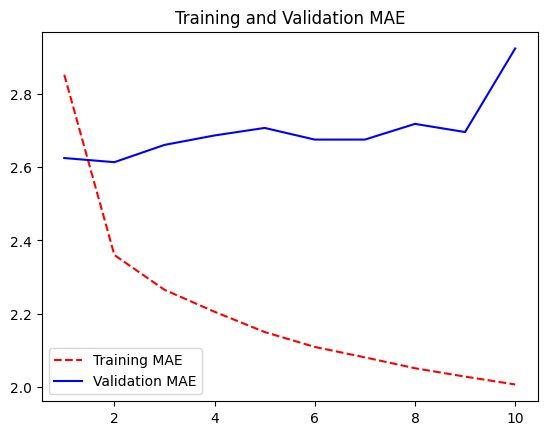

In [46]:
import matplotlib.pyplot as plt

loss= history.history["mae"]
val_loss= history.history["val_mae"]
epochs= range(1,len(loss)+1)
plt.figure()
plt.plot(epochs, loss,"r--",label="Training MAE")
plt.plot(epochs, val_loss,"b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [49]:
inputs= keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x= layers.Conv1D(8,24,activation="relu")(inputs)
x= layers.MaxPooling1D(2)(x)
x= layers.Conv1D(8,12,activation="relu")(x)
x= layers.MaxPooling1D(2)(x)
x= layers.Conv1D(8,6,activation="relu")(x)
x= layers.GlobalAveragePooling1D()(x)
outputs= layers.Dense(1)(x)
model= keras.Model(inputs, outputs)

callbacks= [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(
    optimizer="adam",
    loss= "mse",
    metrics=["mae"],
)
history= model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model= keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")



Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 24.8435 - mae: 3.8771 - val_loss: 15.5703 - val_mae: 3.1167
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 15.1409 - mae: 3.0773 - val_loss: 15.2132 - val_mae: 3.0777
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 12.8263 - mae: 2.8397 - val_loss: 15.4441 - val_mae: 3.0944
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 11.8929 - mae: 2.7298 - val_loss: 14.9276 - val_mae: 3.0495
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 11.2045 - mae: 2.6528 - val_loss: 15.5062 - val_mae: 3.1151
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 10.6936 - mae: 2.5917 - val_loss: 15.1205 - val_mae: 3.0682
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 10.2242 - mae: 2.5336 - val_loss: 15.4853 - val_mae: 3.0939
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 9.8682 - mae: 2.4890 - val_loss: 15.8800 - val_mae: 3.1268
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7

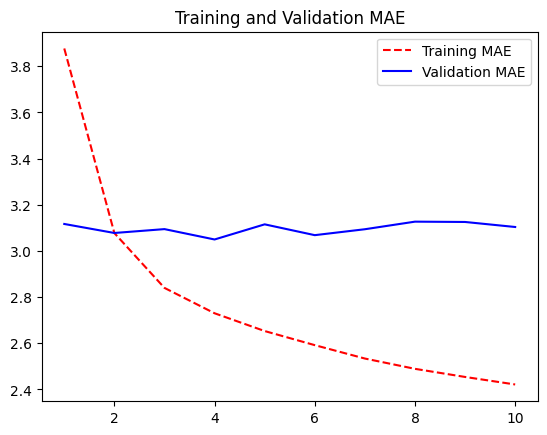

In [50]:
import matplotlib.pyplot as plt

loss= history.history["mae"]
val_loss= history.history["val_mae"]
epochs= range(1,len(loss)+1)
plt.figure()
plt.plot(epochs, loss,"r--",label="Training MAE")
plt.plot(epochs, val_loss,"b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [53]:
inputs= keras.Input(shape=(sequence_length,raw_data.shape[-1]))
x= layers.LSTM(16)(inputs)
outputs= layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks= [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(
    optimizer="adam",
    loss= "mse",
    metrics=["mae"],
)
history= model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model= keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")



Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 39.8768 - mae: 4.6030 - val_loss: 15.0911 - val_mae: 2.9001
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 12.9613 - mae: 2.7484 - val_loss: 10.8429 - val_mae: 2.5235
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 10.2505 - mae: 2.4870 - val_loss: 10.1885 - val_mae: 2.4696
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 9.4187 - mae: 2.3891 - val_loss: 10.0823 - val_mae: 2.4685
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 9.0518 - mae: 2.3380 - val_loss: 9.6929 - val_mae: 2.4239
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 8.5558 - mae: 2.2760 - val_loss: 9.7317 - val_mae: 2.4319
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 8.2406 - mae: 2.2357 - val_loss: 9.9208 - val_mae: 2.4616
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 8.0195 - mae: 2.2098 - val_loss: 10.0023 - val_mae: 2.4750
Epoch 9/10
819/819 ━━━━━━━━━━━━━

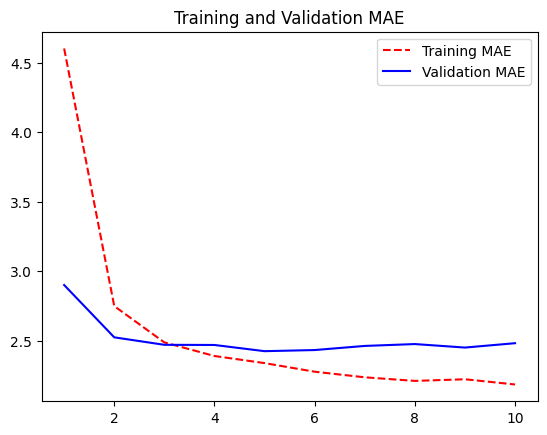

In [54]:
import matplotlib.pyplot as plt

loss= history.history["mae"]
val_loss= history.history["val_mae"]
epochs= range(1,len(loss)+1)
plt.figure()
plt.plot(epochs, loss,"r--",label="Training MAE")
plt.plot(epochs, val_loss,"b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [56]:
import numpy as np
timesteps=100
input_features=32
output_features=64
inputs= np.random.random((timesteps,input_features))
state_t= np.zeros((output_features,))
W= np.random.random((output_features,input_features))
U= np.random.random((output_features,))
successive_outputs= []
b= np.random.random((output_features,))
for input_t in inputs:
    output_t= np.tanh(np.dot(W,input_t)+ np.dot(U,state_t) +b)
    successive_outputs.append(output_t)
    state_t= output_t
final_output_sequence= np.concatenate(successive_outputs,axis=0)

In [58]:
num_features=14
steps=120
inputs= keras.Input(shape=(steps,num_features))
outputs= layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [59]:
num_features=14
steps=120
inputs= keras.Input(shape=(steps,num_features))
outputs= layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [ ]:
inputs= keras.Input(shape=(steps, num_features))
x= layers.SimpleRNN(16,return_sequences=True)(inputs)
x=layers.SimpleRNN(16, return_sequences=True)(x)
outputs= layers.SimpleRNN(16)(x)

In [62]:
inputs= keras.Input(shape=(sequence_length,raw_data.shape[-1]))
x= layers.LSTM(32,recurrent_dropout=0.25)(inputs)
x= layers.Dropout(0.5)(x)
outputs= layers.Dense(1)(x)
model= keras.Model(inputs,outputs)

callbacks= [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
history= model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)


Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 34.6041 - mae: 4.3294 - val_loss: 11.6519 - val_mae: 2.6042
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 16.3752 - mae: 3.1380 - val_loss: 9.7001 - val_mae: 2.4041
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 15.1190 - mae: 3.0227 - val_loss: 9.3846 - val_mae: 2.3720
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 14.3805 - mae: 2.9466 - val_loss: 9.1475 - val_mae: 2.3428
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 13.9115 - mae: 2.8918 - val_loss: 9.1943 - val_mae: 2.3499
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 13.6900 - mae: 2.8692 - val_loss: 9.0335 - val_mae: 2.3244
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 13.2330 - mae: 2.8207 - val_loss: 8.9946 - val_mae: 2.3195
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 13.0336 - mae: 2.7957 - val_loss: 9.0067 - val_mae: 2.3209
Epoch 9/50
819/819 ━━━━━━━━━━━━

In [63]:
model= keras.models.load_model("jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")


405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 9.7422 - mae: 2.4692
Test MAE: 2.47


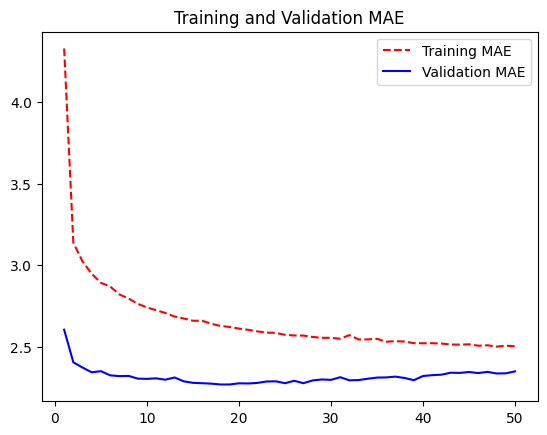

In [64]:
import matplotlib.pyplot as plt

loss= history.history["mae"]
val_loss= history.history["val_mae"]
epochs= range(1,len(loss)+1)
plt.figure()
plt.plot(epochs, loss,"r--",label="Training MAE")
plt.plot(epochs, val_loss,"b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [65]:
inputs= keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x= layers.GRU(32,recurrent_dropout=0.5, return_sequences=True)(inputs)
x= layers.GRU(32,recurrent_dropout= 0.5)(x)
x= layers.Dropout(0.5)(x)
outputs= layers.Dense(1)(x)
model= keras.Model(inputs,outputs)

callbacks= [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss= "mse", metrics= ["mae"])
history= model.fit(
    train_dataset,
    epochs=50,
    validation_data= val_dataset,
    callbacks= callbacks,
)
model= keras.models.load_model("jena_stacked_gru_dropout.keras")
printf(f"Test MAE:{model.evaluate(test_dataset)[1]:.2f}")


Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - loss: 29.2640 - mae: 3.9987 - val_loss: 10.7082 - val_mae: 2.4794
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 15.1305 - mae: 3.0056 - val_loss: 9.3248 - val_mae: 2.3523
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 14.2057 - mae: 2.9129 - val_loss: 9.1054 - val_mae: 2.3325
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 13.6557 - mae: 2.8592 - val_loss: 8.9008 - val_mae: 2.3104
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 13.2607 - mae: 2.8212 - val_loss: 8.8931 - val_mae: 2.3103
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 12.8845 - mae: 2.7777 - val_loss: 8.7761 - val_mae: 2.2969
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 12.5378 - mae: 2.7426 - val_loss: 8.7886 - val_mae: 2.2950
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 12.2499 - mae: 2.7117 - val_loss: 8.7048 - val_mae: 2.2858
Epoch 9/50
819/819 ━━━━━━━━━━━━

ValueError: File not found: filepath=jenas_stacked_gru_dropout.keras. Please ensure the file is an accessible `.keras` zip file.

In [67]:
model= keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE:{model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 9.3694 - mae: 2.4020
Test MAE:2.40


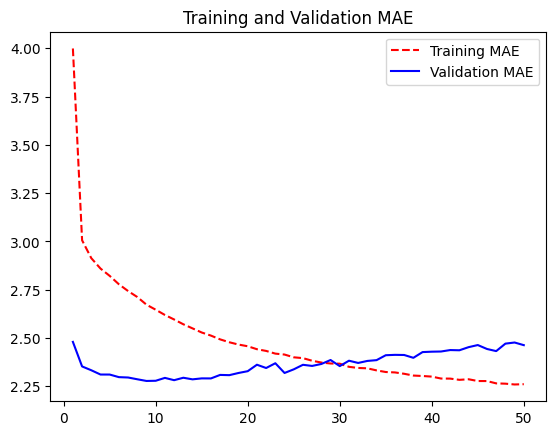

In [68]:
import matplotlib.pyplot as plt

loss= history.history["mae"]
val_loss= history.history["val_mae"]
epochs= range(1,len(loss)+1)
plt.figure()
plt.plot(epochs, loss,"r--",label="Training MAE")
plt.plot(epochs, val_loss,"b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

In [70]:
inputs= keras.Input(shape=(sequence_length,raw_data.shape[-1]))
x= layers.Bidirectional(layers.LSTM(16))(inputs)
outputs= layers.Dense(1)(x)
model= keras.Model(inputs,outputs)
model.compile(optimizer="adam", loss= "mse", metrics= ["mae"])
history= model.fit(
    train_dataset,
    epochs=10,
    validation_data= val_dataset
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 31.9279 - mae: 4.0813 - val_loss: 12.2742 - val_mae: 2.7014
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 11.1954 - mae: 2.6112 - val_loss: 11.9247 - val_mae: 2.7041
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 9.6385 - mae: 2.4197 - val_loss: 10.2811 - val_mae: 2.4956
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 8.8809 - mae: 2.3212 - val_loss: 10.3146 - val_mae: 2.5053
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 8.3290 - mae: 2.2429 - val_loss: 10.4582 - val_mae: 2.5205
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 8.1431 - mae: 2.2228 - val_loss: 10.3032 - val_mae: 2.5041
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 7.6652 - mae: 2.1584 - val_loss: 9.8649 - val_mae: 2.4493
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 7.3712 - mae: 2.1154 - val_loss: 9.9732 - val_mae: 2.4535
Epoch 9/10
819/819 ━━━━━━━━━━━━━